## Flow Matching — Sea Ice Concentration (ASIP / OSISAF)

Conditional Flow Matching (Heun ODE) for SIC reconstruction.
- Target: ASIP SIC (9 time steps, 240×240) — last 9 of 15, contains NaN gaps
- Conditioning: gappy ASIP (input) + OSISAF coarse SIC
- Loss: computed only on non-NaN target pixels

In [1]:
!nvidia-smi

Thu Jun 18 11:12:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   26C    P8             24W /  300W |      17MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%env CUDA_VISIBLE_DEVICES=3

env: CUDA_VISIBLE_DEVICES=3


In [3]:
import math
import os
import zipfile
import glob
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import xarray as xr
import pandas as pd
import torch
from torch import Tensor, nn
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torchinfo import summary

import sys
sys.path.append('../..')      # -> consistency/ (flowmatching_models_FM, spectral_utils)
sys.path.append('../../..')   # -> 4dvarnet-starter-devs/

from flowmatching_models_FM import (
    UNetFM, UNetFMConfig,
    LitFlowMatchingModel, LitFMConfig,
    LogScaleModel,
    heun_sample, euler_sample,
    neglogpdf, neglogcdf,
    sample_uniform_time, masked_average,
)

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("properscoring not installed — CRPS disabled.")

## DataModule — ASIP / OSISAF Sea Ice Concentration

- `batch.asip` (target): ASIP SIC, 9 time steps (last 9 of 15), 240×240 — has NaN gaps
- `batch.input`: gappy ASIP (sparse observations)
- `batch.osisaf`: OSISAF coarse SIC (conditioning)
- Conditioning = `cat(input, osisaf)` → 2C channels
- norm_stats: `[0, 100]` → data normalized to [0, 1]

In [4]:
sys.path.insert(0, '/dmidata/users/maxb/4dvarnet-starter')
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

import functools as ft
from contrib.ASIP_OSISAF.data_simple import BaseDataModule, TrainingItem_4da

T_CROP = 9  # keep last 9 time steps out of 15
SIC_SCALE = 100.0

class CroppedDataModule(BaseDataModule):
    def __init__(self, *args, t_crop=9, **kwargs):
        super().__init__(*args, **kwargs)
        self.t_crop = t_crop

    def build_batch(self):
        return ft.partial(ft.reduce, lambda i, f: f(i), [
            TrainingItem_4da._make,
            lambda item: item._replace(asip=item.asip / SIC_SCALE),
            lambda item: item._replace(input=item.input / SIC_SCALE),
            lambda item: item._replace(osisaf=item.osisaf / SIC_SCALE),
        ])

    def setup(self, stage='test'):
        super().setup(stage)
        for ds in [self.train_ds, self.val_ds, self.test_ds]:
            ds.db = ds.db.isel(time=slice(-self.t_crop, None))

datamodule = CroppedDataModule(
    asip_paths="/dmidata/users/maxb/ASIP_OSISAF_dataset/PREPROC/asip_database_daw15_sparse.nc",
    split_train=slice(0, 300),
    split_val=slice(300, 350),
    split_test=slice(350, 393),
    da=True,
    norm_stats=[0, 100],
    norm_stats_covs=[
        {'t2m': 270.08, 'istl1': 267.68, 'siconc': 0, 'sst': 276.97, 'skt': 270.50},
        {'t2m': 14.67,  'istl1': 7.80,  'siconc': 1, 'sst': 6.82,   'skt': 15.21},
    ],
    t_crop=T_CROP,
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = sample.asip.shape[0]
H, W = sample.asip.shape[1], sample.asip.shape[2]
print(f"C={C}, H={H}, W={W}")
print(f"Train: {len(datamodule.train_ds)}, Val: {len(datamodule.val_ds)}, Test: {len(datamodule.test_ds)}")
print(f"asip: {sample.asip.shape}  input: {sample.input.shape}  osisaf: {sample.osisaf.shape}")
print(f"asip range: [{np.nanmin(sample.asip):.3f}, {np.nanmax(sample.asip):.3f}]")
print(f"asip std: {np.nanstd(sample.asip):.4f}")
print(f"NaN fraction in asip: {np.isnan(sample.asip).mean()*100:.1f}%")

fig, axes = plt.subplots(3, min(C, 5), figsize=(3 * min(C, 5), 9))
for t_idx in range(min(C, 5)):
    axes[0, t_idx].imshow(sample.asip[t_idx], vmin=0, vmax=1, cmap='Blues_r')
    axes[0, t_idx].set_title(f't={t_idx}', fontsize=8); axes[0, t_idx].axis('off')
    axes[1, t_idx].imshow(sample.input[t_idx], vmin=0, vmax=1, cmap='Blues_r')
    axes[1, t_idx].axis('off')
    axes[2, t_idx].imshow(sample.osisaf[t_idx], vmin=0, vmax=1, cmap='Blues_r')
    axes[2, t_idx].axis('off')
axes[0, 0].set_ylabel('ASIP (target)', fontsize=10)
axes[1, 0].set_ylabel('Input (gappy)', fontsize=10)
axes[2, 0].set_ylabel('OSISAF (cond.)', fontsize=10)
plt.tight_layout()
plt.show()

### UNetFM — Velocity-prediction network

Input: `cat(x_t, y_cond_filled, mask_cond)` where `y_cond = cat(input, osisaf)` → C + 2×2C = 5C channels.

Uses `cond_channels=2*C` in UNetFMConfig to handle the wider conditioning.

In [5]:
cfg = UNetFMConfig(channels=C, cond_channels=2*C)
net = UNetFM(cfg)

y_dummy = torch.cat([torch.randn(1, C, H, W), torch.randn(1, C, H, W)], dim=1)

summary(
    net,
    input_size=(
        (1, C, H, W),     # x_t
        (1, 2*C, H, W),   # y_cond = cat(input, osisaf)
        (1,),              # t
    ),
)

Layer (type:depth-idx)                        Output Shape              Param #
UNetFM                                        [1, 9, 240, 240]          --
├─Conv2d: 1-1                                 [1, 64, 240, 240]         25,984
├─TimeEmbedding: 1-2                          [1, 128, 1, 1]            64
│    └─Sequential: 2-1                        [1, 128, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
│    │    └─Rearrange: 3-4                    [1, 128, 1, 1]            --
├─ModuleList: 1-3                             --                        --
│    └─UNetBlock: 2-2                         [1, 64, 240, 240]         --
│    │    └─Sequential: 3-5                   [1, 64, 240, 240]         37,056
│    │    └─Sequential: 3-6                   [1, 64, 1, 1]             8,256
│

### LitFlowMatchingSIC — masked loss for gappy target

Overrides the training step to:
1. Build conditioning `y = cat(input, osisaf)`
2. Mask loss to non-NaN pixels in the ASIP target
3. Fill NaN in target before building the interpolant

In [6]:
class LitFlowMatchingSIC(LitFlowMatchingModel):

    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        x1_raw = batch.asip                                           # (B, C, H, W) with NaN
        y      = torch.cat((batch.input, batch.osisaf), dim=1)       # (B, 2C, H, W)
        B, C, H, W = x1_raw.shape

        valid = ~torch.isnan(x1_raw)                                 # (B, C, H, W)
        x1    = torch.nan_to_num(x1_raw, nan=0.0)                   # fill for interpolant

        t      = sample_uniform_time(x1)
        t_flat = t.view(B)
        noise  = torch.randn_like(x1)
        x_t    = t * x1 + (1.0 - t) * noise
        v_tgt  = x1 - noise

        v_pred = self.network(x_t, y, t_flat)

        log_s    = self.log_scale(t_flat).view(B, C, 1, 1).expand_as(v_pred)
        residual = (v_tgt - v_pred) / log_s.exp().clamp(min=1e-5)
        loss_map = neglogpdf(residual, log_s)

        loss = masked_average(loss_map, valid)

        self.log("train_loss", loss, prog_bar=True, on_step=True, on_epoch=True)
        return loss

    def on_train_epoch_end(self) -> None:
        if self._val_batch is None:
            return
        device = self.device
        dtype  = next(self.network.parameters()).dtype

        x_gt_raw = self._val_batch.asip.to(device=device, dtype=dtype)
        y = torch.cat((
            self._val_batch.input.to(device=device, dtype=dtype),
            self._val_batch.osisaf.to(device=device, dtype=dtype),
        ), dim=1)

        valid = ~torch.isnan(x_gt_raw)
        x_gt  = torch.nan_to_num(x_gt_raw, nan=0.0)

        ema_net = self.ema_model.module.to(device=device, dtype=dtype)
        ema_net.eval()

        noise = torch.randn_like(x_gt)
        x_hat, _ = heun_sample(ema_net, noise, y, n_steps=self.config.eval_n_steps)

        err = (x_hat.float() - x_gt.float()).pow(2)
        rmse = (err[valid].mean()).sqrt().item()
        print(f"[Epoch {self.current_epoch}]  Val RMSE (masked, EMA) = {rmse:.4f}")
        self.log("val_rmse_ema", rmse)

    def on_fit_start(self) -> None:
        try:
            dl = self.trainer.datamodule.val_dataloader()
            batch = next(iter(dl))
            if isinstance(batch, list):
                batch = batch[0]
            self._val_batch = batch
            print(f"Val batch cached: asip={batch.asip.shape}")
        except Exception as e:
            print(f"Could not cache val batch: {e}")

print("LitFlowMatchingSIC defined")

LitFlowMatchingSIC defined


## Training

In [7]:
%tensorboard --logdir=logs_FM_sic --port 6011

UsageError: Line magic function `%tensorboard` not found.


In [ ]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last) and is_valid_checkpoint(last):
        print(f"Valid checkpoint: {last}")
        return last
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt")) if "last" not in p],
        key=lambda p: float(p.split("train_loss=")[-1].replace(".ckpt", ""))
        if "train_loss=" in p else float("inf"),
    )
    for p in all_ckpts:
        if is_valid_checkpoint(p):
            print(f"Valid checkpoint: {p}")
            return p
    print("No valid checkpoint found. Starting from scratch.")
    return None

LOG_DIR     = "logs_FM_sic"
CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, "best_model")

RESET_TRAINING = True
if RESET_TRAINING:
    import shutil
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
    resume_ckpt = None
    print("RESET_TRAINING=True -- starting from scratch")
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

network = UNetFM(UNetFMConfig(channels=C, cond_channels=2*C))
lit_fm  = LitFlowMatchingSIC(
    network=network,
    config=LitFMConfig(lr_scheduler_iters=1000, eval_n_steps=20),
)

trainer = Trainer(
    accelerator="gpu",
    max_epochs=1000,
    accumulate_grad_batches=4,
    precision="16-mixed",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=""),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="train_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.fit(lit_fm, datamodule, ckpt_path=resume_ckpt)

ema_net = lit_fm.ema_model.module
ema_net.save_pretrained(MODEL_PATH)
print(f"EMA model saved to: {MODEL_PATH}")

## Sampling & Evaluation

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32

MODEL_PATH = os.path.join("logs_FM_sic", "best_model")

ema_unet = UNetFM.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"EMA UNetFM loaded from {MODEL_PATH}")
print(f"  Params : {sum(p.numel() for p in ema_unet.parameters()):,}")

EMA UNetFM loaded from logs_FM_sic/v1/best_model
  Params : 32,289,417


### Test Batch

In [32]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

x_gt_raw = batch.asip.to(device=device, dtype=dtype)     # (B, C, H, W) with NaN
y_cond   = torch.cat((
    batch.input.to(device=device, dtype=dtype),
    batch.osisaf.to(device=device, dtype=dtype),
), dim=1)                                                  # (B, 2C, H, W)

B, C, H, W = x_gt_raw.shape
valid_mask = ~torch.isnan(x_gt_raw)
x_gt = torch.nan_to_num(x_gt_raw, nan=0.0)

m_norm, s_norm = datamodule.norm_stats()
print(f"Test batch  asip:{tuple(x_gt_raw.shape)}  y_cond:{tuple(y_cond.shape)}")
print(f"NaN fraction in target: {(~valid_mask).float().mean()*100:.1f}%")

Global seed set to 42


Test batch  asip:(2, 9, 240, 240)  y_cond:(2, 18, 240, 240)
NaN fraction in target: 54.1%


### Ensemble Generation (N_SAMPLES members)

In [33]:
N_SAMPLES = 10
N_STEPS   = 20

samples = []

with torch.no_grad():
    for s in range(N_SAMPLES):
        noise = torch.randn_like(x_gt)
        x_pred, _ = heun_sample(ema_unet, noise, y_cond, n_steps=N_STEPS)
        samples.append(x_pred.cpu())
        print(f"  member {s+1}/{N_SAMPLES} done", end="\r")

samples = torch.stack(samples, dim=0)   # (N, B, C, H, W)
print(f"\nEnsemble: {tuple(samples.shape)}")

ens_mean = samples.mean(0)
ens_std  = samples.std(0)

_b = 0
ens_mean_1 = ens_mean[_b]   # (C, H, W)
ens_std_1  = ens_std[_b]
ensemble_1 = samples[:, _b]
gt_valid_1 = valid_mask[_b].cpu()

  member 10/10 done
Ensemble: (10, 2, 9, 240, 240)


## Metrics — FM vs GT (masked)

Metrics computed only on non-NaN pixels of the ASIP target.

| Metric | Description |
|---|---|
| **Score** | $1 - \text{RMSE}/\sigma_{\text{GT}}$ |
| **RMSE** | Root Mean Square Error (masked) |
| **CRPS** | Continuous Ranked Probability Score at valid pixels |
| **lambda_x** | Resolved scale (px) at spectral score = 0.5 |

t=4 | sigma(GT)=1.7229 | valid coverage=61.1%

## Metrics @ t=4 (masked)



,Score,RMSE,sigma_GT,sigma_pred,CRPS,lambda_x [px]
Method,,,,,,
FM (ens. mean),-0.512,2.6053,1.7229,2.3645,2.9761,?


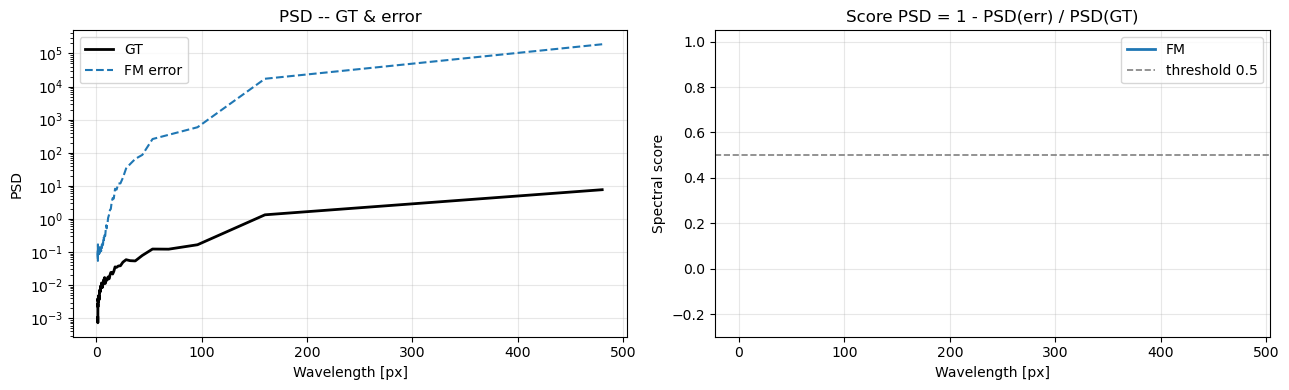

In [34]:
import sys
sys.path.append('../..')
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale

T_EVAL = C // 2
DX = 1.0   # pixel spacing (px)

gt_n   = batch.asip[_b, T_EVAL].float().cpu().numpy()
gt_p   = gt_n * s_norm + m_norm   # physical SIC (%)

mean_n = ens_mean_1[T_EVAL].float().cpu().numpy()
mean_p = mean_n * s_norm + m_norm

ens_n  = ensemble_1[:, T_EVAL].float().cpu().numpy()
ens_p  = ens_n * s_norm + m_norm

valid_t = gt_valid_1[T_EVAL].numpy()   # bool mask for non-NaN pixels

# Fill NaN for spectral computation (NaN breaks FFT)
gt_filled   = np.nan_to_num(gt_p, nan=0.0)
mean_filled = np.nan_to_num(mean_p, nan=0.0)

sigma_gt = float(np.nanstd(gt_p))
print(f't={T_EVAL} | sigma(GT)={sigma_gt:.4f} | valid coverage={valid_t.mean()*100:.1f}%')

def _metrics_row(pred_p, gt_p, label, valid, ens_p_arr=None, dx=DX):
    gt_v   = gt_p[valid]
    pred_v = pred_p[valid]
    sigma  = float(np.std(gt_v))
    rmse   = float(np.sqrt(np.mean((pred_v - gt_v) ** 2)))
    score  = 1.0 - rmse / sigma if sigma > 0 else np.nan
    sigma_pred = float(np.std(pred_v))
    # Spectral on filled fields (NaN replaced by 0)
    gt_f   = np.nan_to_num(gt_p, nan=0.0)
    pred_f = np.nan_to_num(pred_p, nan=0.0)
    wl, _, _, spec = psd_spectral_score(pred_f, gt_f, dx=dx)
    lambda_x = resolved_scale(wl, spec, threshold=0.5)
    crps_val = np.nan
    if ens_p_arr is not None and HAS_PROPERSCORING:
        obs_ij = np.argwhere(valid)
        if len(obs_ij) > 0:
            crps_val = float(np.mean([
                crps_ensemble(float(gt_p[i, j]), ens_p_arr[:, i, j])
                for i, j in obs_ij[:500]
            ]))
    return {
        'Method'    : label,
        'Score'     : f'{score:.3f}',
        'RMSE'      : f'{rmse:.4f}',
        'sigma_GT'  : f'{sigma:.4f}',
        'sigma_pred': f'{sigma_pred:.4f}',
        'CRPS'      : f'{crps_val:.4f}' if not np.isnan(crps_val) else '--',
        'lambda_x'  : f'{lambda_x:.1f}' if not np.isnan(lambda_x) else '?',
    }, wl, spec

row_fm, wl_fm, spec_fm = _metrics_row(mean_p, gt_p, 'FM (ens. mean)',
                                       valid_t, ens_p_arr=ens_p)

df_metrics = pd.DataFrame([row_fm]).set_index('Method')
df_metrics.columns = ['Score','RMSE','sigma_GT','sigma_pred','CRPS','lambda_x [px]']
print(f'\n## Metrics @ t={T_EVAL} (masked)\n')
display(df_metrics)

# ── Spectral plots ──────────────────────────────────────────────────────
_, psd_gt_r, psd_err_fm, _ = psd_spectral_score(mean_filled, gt_filled, dx=DX)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
valid_s = np.isfinite(wl_fm) & np.isfinite(psd_gt_r) & (psd_gt_r > 0)
ax.semilogy(wl_fm[valid_s], psd_gt_r[valid_s],  'k-',   lw=2,   label='GT')
valid_e = np.isfinite(wl_fm) & np.isfinite(psd_err_fm) & (psd_err_fm > 0)
ax.semilogy(wl_fm[valid_e], psd_err_fm[valid_e], 'C0--', lw=1.5, label='FM error')
ax.set_xlabel('Wavelength [px]')
ax.set_ylabel('PSD')
ax.set_title('PSD -- GT & error')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
lambda_x_fm = resolved_scale(wl_fm, spec_fm)
lbl = f'FM (lambda_x={lambda_x_fm:.1f} px)' if not np.isnan(lambda_x_fm) else 'FM'
valid_sc = np.isfinite(wl_fm) & np.isfinite(spec_fm)
ax.plot(wl_fm[valid_sc], spec_fm[valid_sc], 'C0-', lw=2, label=lbl)
ax.axhline(0.5, color='gray', lw=1.2, ls='--', label='threshold 0.5')
if not np.isnan(lambda_x_fm):
    ax.axvline(lambda_x_fm, color='C0', lw=1, ls=':')
ax.set_xlabel('Wavelength [px]')
ax.set_ylabel('Spectral score')
ax.set_title('Score PSD = 1 - PSD(err) / PSD(GT)')
ax.set_ylim(-0.3, 1.05)
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Publication Figures — SIC comparison & uncertainty

  Saved: figures/FM_sic/FM_sic_asip_gt.png


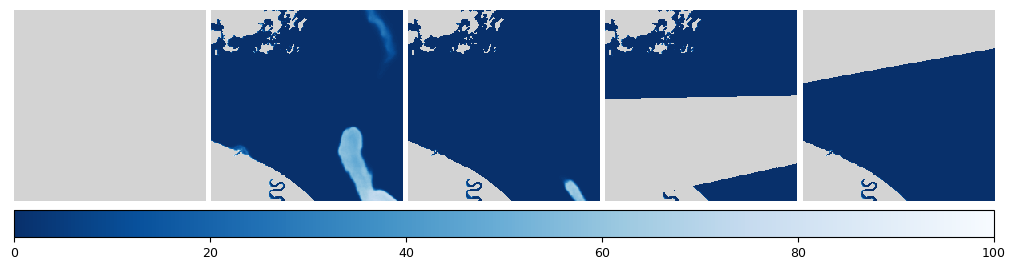

  Saved: figures/FM_sic/FM_sic_input.png


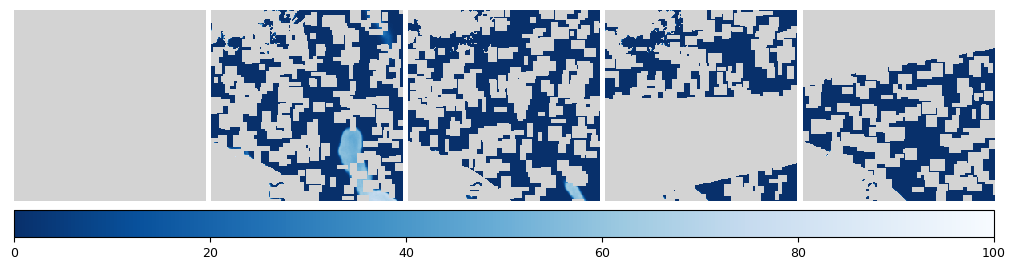

  Saved: figures/FM_sic/FM_sic_osisaf.png


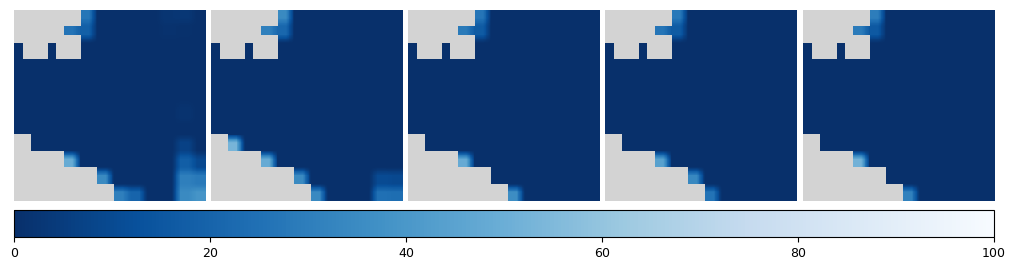

  Saved: figures/FM_sic/FM_sic_fm_mean.png


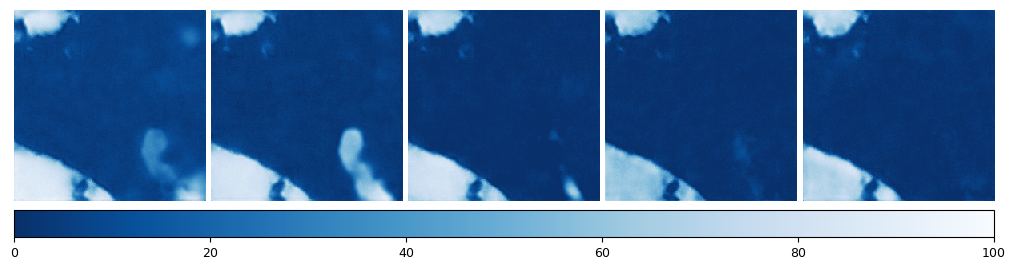

  Saved: figures/FM_sic/FM_sic_fm_spread.png


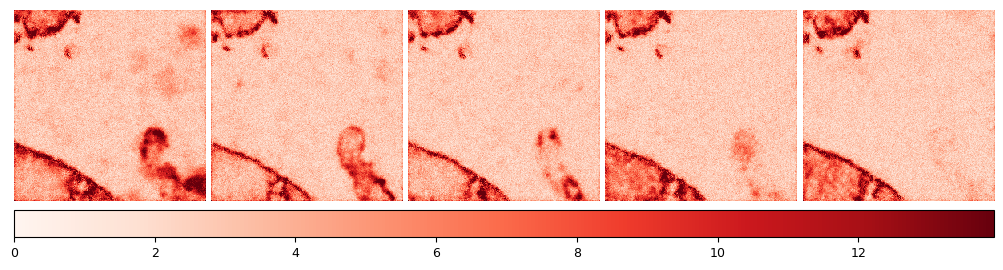

  Saved: figures/FM_sic/FM_sic_member0.png


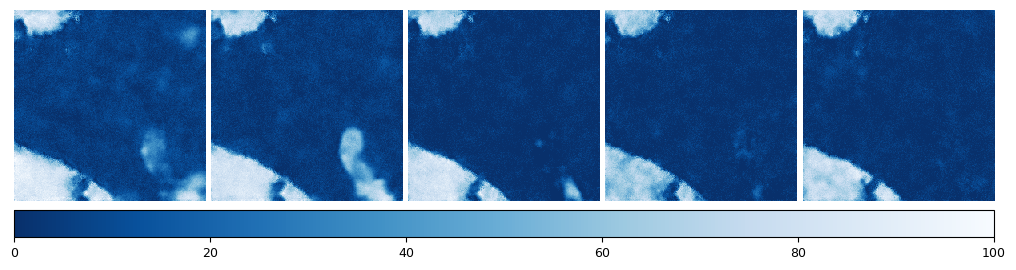

In [35]:
from matplotlib.gridspec import GridSpec

FIG_TAG = 'FM_sic'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

N_SHOW = min(C, 5)

asip_phys  = batch.asip[_b, :N_SHOW].float().cpu().numpy() * s_norm + m_norm
input_phys = batch.input[_b, :N_SHOW].float().cpu().numpy() * s_norm + m_norm
osi_phys   = batch.osisaf[_b, :N_SHOW].float().cpu().numpy() * s_norm + m_norm
mean_phys  = ens_mean_1[:N_SHOW].float().cpu().numpy() * s_norm + m_norm
std_phys   = ens_std_1[:N_SHOW].float().cpu().numpy() * s_norm
mbr0_phys  = ensemble_1[0, :N_SHOW].float().cpu().numpy() * s_norm + m_norm

cmap_sic = plt.cm.Blues_r.copy(); cmap_sic.set_bad('lightgray')
cmap_std = plt.cm.Reds.copy();   cmap_std.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap, ncols=None):
    nc = ncols or data.shape[0]
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = nc * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, nc, left=0.01, right=0.99, top=0.99, bottom=0.01,
                  height_ratios=[FH, CB_H], hspace=0.06, wspace=0.03)
    for c in range(nc):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

vmax_s = float(np.nanpercentile(std_phys, 99))

for data, fname, vmin, vmax, cmap in [
    (asip_phys,  f'{FIG_TAG}_asip_gt',   0, 100, cmap_sic),
    (input_phys, f'{FIG_TAG}_input',     0, 100, cmap_sic),
    (osi_phys,   f'{FIG_TAG}_osisaf',    0, 100, cmap_sic),
    (mean_phys,  f'{FIG_TAG}_fm_mean',   0, 100, cmap_sic),
    (std_phys,   f'{FIG_TAG}_fm_spread', 0, vmax_s, cmap_std),
    (mbr0_phys,  f'{FIG_TAG}_member0',   0, 100, cmap_sic),
]:
    _save_strip(data, fname, vmin, vmax, cmap, ncols=N_SHOW)

### ODE Transport Process — Heun trajectory

  Saved: figures/FM_sic/FM_sic_transport.png


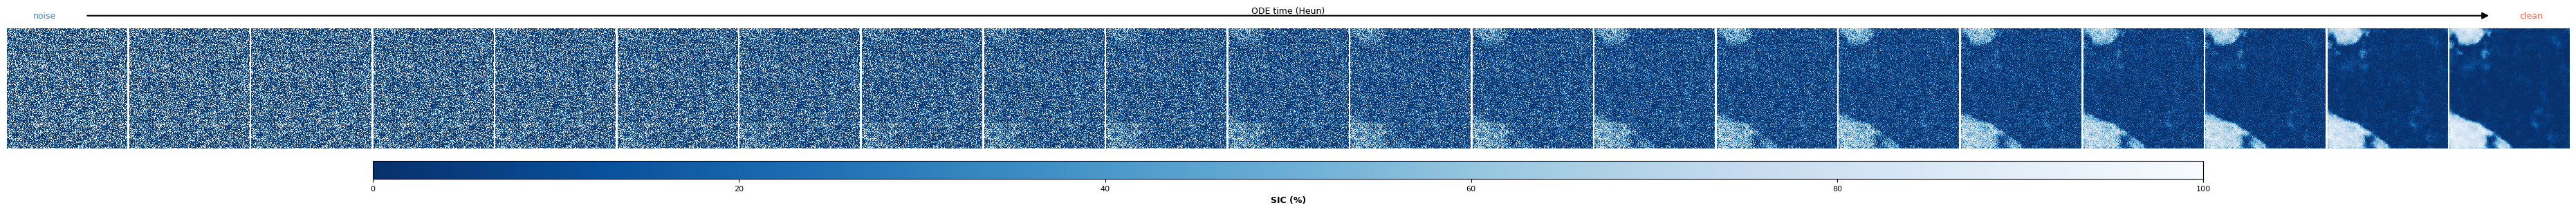

In [27]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

T_CH   = C // 2
N_SHOW = 10

N_VIZ_STEPS = 20
torch.manual_seed(42)
noise_traj = torch.randn(1, C, H, W, device=device, dtype=dtype)
y_traj     = y_cond[0:1]

with torch.no_grad():
    _, trajectory = heun_sample(ema_unet, noise_traj, y_traj, n_steps=N_VIZ_STEPS)

transport_n = torch.stack(trajectory, dim=0)[:, 0, T_CH, :, :].float().cpu().numpy()
transport_p = transport_n * s_norm + m_norm

nfr = transport_p.shape[0]
stride = max(1, nfr // N_SHOW)
idx_show = list(range(0, nfr, stride))
if (nfr - 1) not in idx_show:
    idx_show.append(nfr - 1)
frames = transport_p[idx_show]
nf = len(frames)

FW, FH   = 2.4, 2.4
ARR_H    = 0.28
GAP_1    = 0.14
CB_H     = 0.26
GAP_2    = 0.16

fig_w = nf * FW
fig_h = ARR_H + GAP_1 + CB_H + GAP_2 + FH

arr_y_f   = (ARR_H / 2) / fig_h
cb_bot_f  = (ARR_H + GAP_1) / fig_h
cb_h_f    = CB_H / fig_h
img_bot_f = (ARR_H + GAP_1 + CB_H + GAP_2) / fig_h

fig = plt.figure(figsize=(fig_w, fig_h))
gs = GridSpec(1, nf, left=0.01, right=0.99, top=0.99, bottom=img_bot_f,
              hspace=0, wspace=0.02)

cmap_t = plt.cm.Blues_r
for i in range(nf):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(frames[i], origin='lower', cmap=cmap_t,
              vmin=0, vmax=100, interpolation='nearest')
    ax.axis('off')

cb_ax = fig.add_axes([0.15, cb_bot_f, 0.70, cb_h_f])
sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(0, 100))
sm.set_array([])
cb = fig.colorbar(sm, cax=cb_ax, orientation='horizontal')
cb.set_label('SIC (%)', fontsize=24, fontweight='bold')
cb.ax.tick_params(labelsize=20)

fig.add_artist(mpatches.FancyArrowPatch(
    (0.04, 1+arr_y_f), (0.96, 1+arr_y_f),
    transform=fig.transFigure, arrowstyle='-|>',
    color='black', mutation_scale=32, linewidth=1.5,
))
fig.text(0.02, 1+arr_y_f, 'noise', va='bottom', ha='left',  fontsize=24, color='steelblue')
fig.text(0.98, 1+arr_y_f, 'clean', va='bottom', ha='right', fontsize=24, color='tomato')
fig.text(0.50, 1+arr_y_f, 'ODE time (Heun)', va='bottom', ha='center', fontsize=24)

fpath = os.path.join(FIG_DIR, f'{FIG_TAG}_transport.png')
fig.savefig(fpath, dpi=200, bbox_inches='tight')
print(f'  Saved: {fpath}')
plt.show()